**Control Bonds**

In [6]:
import sys
import os
import pandas as pd

_HERE = os.getcwd()
_ROOT = os.path.dirname(_HERE)
sys.path.insert(0, _ROOT)
sys.path.insert(0, _HERE)

DATABASE_DIR = os.path.join(_ROOT, 'Database')

bonds = pd.read_parquet(os.path.join(DATABASE_DIR, 'bonds.parquet'))

dates = bonds.index.get_level_values('Date')
print(f'Date range: {dates.min().date()} to {dates.max().date()}')

nan_mask = bonds.isna().any(axis=1)
print(f'Rows with at least one NaN: {nan_mask.sum()} / {len(bonds)}')

nan_by_ticker = (
    bonds[nan_mask]
    .index.to_frame(index=False)
    .groupby('Ticker')['Date']
    .agg(count='count', first='min', last='max')
)
print('\nNaN occurrences by ticker:')
print(nan_by_ticker)

bonds

Date range: 2000-01-03 to 2026-07-30
Rows with at least one NaN: 0 / 86385

NaN occurrences by ticker:
Empty DataFrame
Columns: [count, first, last]
Index: []


Close    High        Low    Open    Volume  Yield  \
Date       Ticker                                                          
2000-01-03 ^FVX     0.000000   6.473   6.411000   6.411       0.0  6.457   
           ^IRX     0.000000   5.300   5.230000   5.230       0.0  5.270   
           ^TNX     0.000000   6.603   6.498000   6.498       0.0  6.548   
           ^TYX     0.000000   6.598   6.537000   6.537       0.0  6.598   
2000-01-04 ^FVX     0.000000   6.450   6.388000   6.434       0.0  6.396   
...                      ...     ...        ...     ...       ...    ...   
2026-07-30 TMV     42.119999  42.520  41.939999  42.090  797500.0  0.000   
           ^FVX     0.000000   4.403   4.359000   4.389       0.0  4.375   
           ^IRX     0.000000   3.675   3.647000   3.668       0.0  3.675   
           ^TNX     0.000000   4.686   4.651000   4.669       0.0  4.663   
           ^TYX     0.000000   5.228   5.192000   5.199       0.0  5.208   

                                                              Name  
Date       Ticker                                                   
2000-01-03 ^FVX                    CBOE 5-Year Treasury Note Yield  
           ^IRX                   CBOE 13-Week Treasury Bill Yield  
           ^TNX                   CBOE 10-Year Treasury Note Yield  
           ^TYX                   CBOE 30-Year Treasury Bond Yield  
2000-01-04 ^FVX                    CBOE 5-Year Treasury Note Yield  
...                                                            ...  
2026-07-30 TMV     Direxion Daily 20+ Year Treasury Bear 3X Shares  
           ^FVX                    CBOE 5-Year Treasury Note Yield  
           ^IRX                   CBOE 13-Week Treasury Bill Yield  
           ^TNX                   CBOE 10-Year Treasury Note Yield  
           ^TYX                   CBOE 30-Year Treasury Bond Yield  

[86385 rows x 7 columns]

**Visualize Bonds**

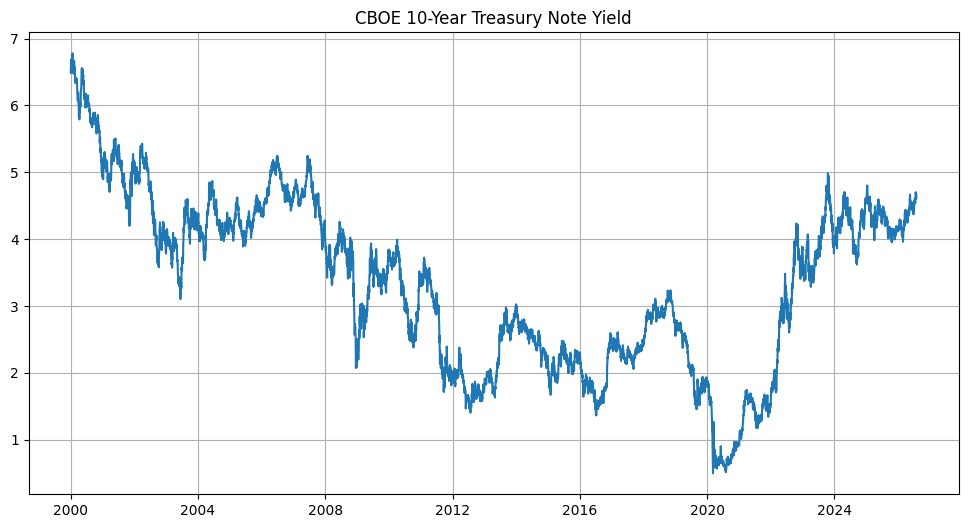

In [13]:
import matplotlib.pyplot as plt

df = pd.read_parquet(os.path.join(DATABASE_DIR, 'bonds.parquet'))

ticker = '^TNX'
data  = 'Yield'         # Yield for Indices, Close for ETFs

name = df["Name"].xs(ticker, level="Ticker").iloc[0]

plt.figure(figsize=(12,6))

plt.plot(df[data].xs(ticker, level="Ticker"))
plt.title(name)
plt.grid(True)

plt.show()